# Modeling

In [1]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_train = pd.read_csv('../data/data_model/train_model.csv', sep=',')

In [3]:
X = df_train.drop(columns=['SALEPRICE'])
y = df_train['SALEPRICE']

In [4]:
df_train.head()

,NEIGHBORHOOD,OVERALLQUAL,EXTERQUAL,BSMTQUAL,HEATINGQC,GRLIVAREA,KITCHENQUAL,TOTRMSABVGRD,GARAGEYRBLT,GARAGEFINISH,...,EXTERIOR1ST_OTHER,EXTERIOR1ST_PLYWOOD,EXTERIOR1ST_VINYLSD,EXTERIOR1ST_WD SDNG,GARAGETYPE_DETCHD,GARAGETYPE_OTHER,SALETYPE_CON,SALETYPE_NEW,SALETYPE_WD,SALEPRICE
0,0.483681,0.550585,0.930835,0.491996,0.814688,0.531594,0.636941,0.969273,0.916845,0.123461,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,12.247699
1,1.142755,-0.233625,-0.827054,0.491996,0.814688,-0.472592,-0.935418,-0.338533,-0.282761,0.123461,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,12.109016
2,0.483681,0.550585,0.930835,0.491996,0.814688,0.675348,0.636941,-0.338533,0.827986,0.123461,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,12.317171
3,1.801830,1.334796,0.930835,0.491996,0.814688,1.361584,0.636941,1.623175,0.783556,0.123461,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,12.429220
4,0.977986,1.334796,0.930835,1.996684,0.814688,0.500517,0.636941,0.315370,0.961275,0.123461,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,12.634606


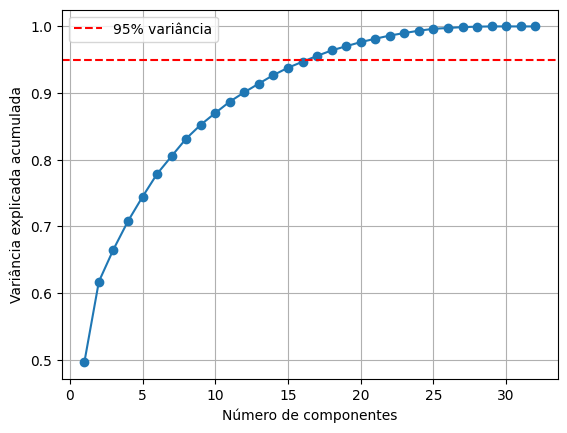

In [ ]:
pca = PCA() 
pca.fit(X)

variancia_acumulada = pca.explained_variance_ratio_.cumsum()

plt.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variância')
plt.xlabel('Número de componentes')
plt.ylabel('Variância explicada acumulada')
plt.legend()
plt.grid(True)
plt.show()

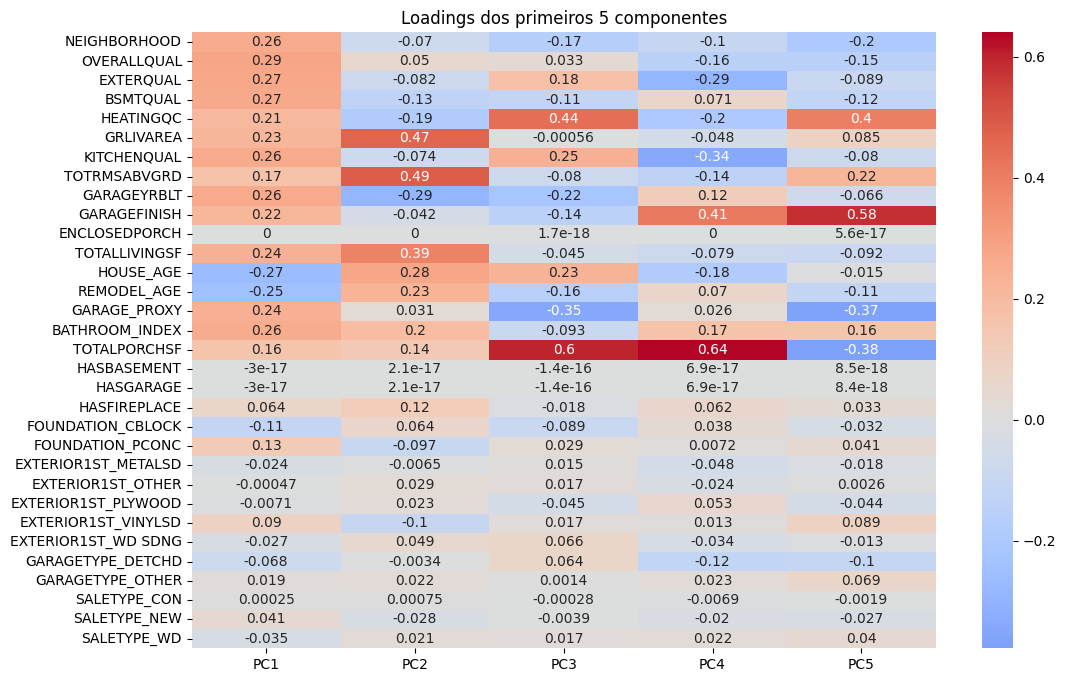

In [6]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    loadings.iloc[:, :5],  # primeiros 5 componentes
    annot=True,
    cmap='coolwarm',
    center=0
)
plt.title('Loadings dos primeiros 5 componentes')
plt.show()

In [7]:
X = X.drop(columns=['ENCLOSEDPORCH', 'HASBASEMENT', 'HASGARAGE'])

In [8]:
pca = PCA()
pca.fit(X)

variancia_individual = pca.explained_variance_ratio_
variancia_acumulada = variancia_individual.cumsum()

tabela = pd.DataFrame({
    'Componente': range(1, len(variancia_acumulada) + 1),
    'Variância Individual (%)': (variancia_individual * 100).round(4),
    'Variância Acumulada (%)': (variancia_acumulada * 100).round(4),
    'Delta (%)': (pd.Series(variancia_acumulada).diff().fillna(variancia_acumulada[0]) * 100).round(4)
})

print(tabela.to_string(index=False))

 Componente  Variância Individual (%)  Variância Acumulada (%)  Delta (%)
          1                   49.5878                  49.5878    49.5878
          2                   12.1242                  61.7121    12.1242
          3                    4.8169                  66.5290     4.8169
          4                    4.2490                  70.7779     4.2490
          5                    3.6542                  74.4322     3.6542
          6                    3.4344                  77.8666     3.4344
          7                    2.6685                  80.5351     2.6685
          8                    2.6296                  83.1647     2.6296
          9                    2.0756                  85.2404     2.0756
         10                    1.7646                  87.0050     1.7646
         11                    1.7104                  88.7154     1.7104
         12                    1.4029                  90.1183     1.4029
         13                    1.3093 